In [12]:
import torch
from utils.Encoder_model import make_Encoder_model

try:
    from thop import profile, clever_format
    THOP_AVAILABLE = True
except Exception:
    THOP_AVAILABLE = False

In [ ]:
# Memory estimation and measurement utilities for PyTorch models

import torch
from typing import Iterable, Optional, Tuple, Dict, Any


def _tensor_nbytes(t: torch.Tensor) -> int:
    return t.numel() * t.element_size()


def count_model_bytes(model: torch.nn.Module, include_buffers: bool = True) -> Tuple[int, int, int]:
    """
    Returns (param_bytes, grad_bytes, buffer_bytes) for the model.
    grad_bytes assumes gradients are allocated (same shape/dtype as params).
    """
    param_bytes = sum(_tensor_nbytes(p) for p in model.parameters())
    grad_bytes = sum(_tensor_nbytes(p) for p in model.parameters() if p.grad is not None)
    if include_buffers:
        buffer_bytes = sum(_tensor_nbytes(b) for b in model.buffers())
    else:
        buffer_bytes = 0
    return param_bytes, grad_bytes, buffer_bytes


def count_optimizer_state_bytes(optimizer: Optional[torch.optim.Optimizer]) -> int:
    """
    Sums sizes of tensors in optimizer.state.
    Works for Adam/AdamW/SGD etc. Returns 0 if optimizer is None.
    """
    if optimizer is None:
        return 0
    total = 0
    for state in optimizer.state.values():
        if isinstance(state, dict):
            for v in state.values():
                if isinstance(v, torch.Tensor):
                    total += _tensor_nbytes(v)
        elif isinstance(state, torch.Tensor):
            total += _tensor_nbytes(state)
    return total


def format_bytes(nbytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(nbytes)
    i = 0
    while size >= 1024.0 and i < len(units) - 1:
        size /= 1024.0
        i += 1
    return f"{size:.2f} {units[i]}"


def estimate_inference_memory_static(model: torch.nn.Module) -> Dict[str, Any]:
    """
    Theoretical static footprint for inference (no activations):
    - Parameters + buffers only. Activations depend on input and are runtime-dependent.
    """
    param_b, _, buffer_b = count_model_bytes(model, include_buffers=True)
    total = param_b + buffer_b
    return {
        "params_bytes": param_b,
        "buffers_bytes": buffer_b,
        "total_static_inference_bytes": total,
        "pretty": {
            "params": format_bytes(param_b),
            "buffers": format_bytes(buffer_b),
            "total_static_inference": format_bytes(total),
        },
    }


def estimate_training_memory_static(model: torch.nn.Module, optimizer: Optional[torch.optim.Optimizer] = None) -> Dict[str, Any]:
    """
    Static lower-bound for training (still no activations):
    - Parameters + buffers + gradients (+ optimizer state if provided).
    """
    param_b, grad_b_existing, buffer_b = count_model_bytes(model, include_buffers=True)
    # If grads not allocated yet, assume they'll equal params in size
    grad_b = grad_b_existing if grad_b_existing > 0 else param_b
    opt_b = count_optimizer_state_bytes(optimizer)
    total = param_b + buffer_b + grad_b + opt_b
    return {
        "params_bytes": param_b,
        "buffers_bytes": buffer_b,
        "grads_bytes": grad_b,
        "optimizer_state_bytes": opt_b,
        "total_static_training_bytes": total,
        "pretty": {
            "params": format_bytes(param_b),
            "buffers": format_bytes(buffer_b),
            "grads": format_bytes(grad_b),
            "optimizer_state": format_bytes(opt_b),
            "total_static_training": format_bytes(total),
        },
    }


class PeakCudaMemory:
    """Context manager to measure CUDA peak memory (allocated + reserved)."""

    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
        return self

    def __exit__(self, exc_type, exc, tb):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    @staticmethod
    def read() -> Dict[str, int]:
        if not torch.cuda.is_available():
            return {"allocated": 0, "reserved": 0}
        return {
            "allocated": torch.cuda.max_memory_allocated(),
            "reserved": torch.cuda.max_memory_reserved(),
        }


def measure_inference_peak_memory(
    model: torch.nn.Module,
    sample_inputs: Iterable[torch.Tensor] | torch.Tensor,
    device: Optional[torch.device] = None,
    dtype: Optional[torch.dtype] = None,
    warmup: int = 1,
    steps: int = 1,
) -> Dict[str, Any]:
    """
    Runs a few forward passes and reports CUDA peak memory.
    If CUDA is not available, returns zeros for peaks but still returns static estimates.
    """
    model_was_training = model.training
    model.eval()

    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    def _to(x):
        if isinstance(x, torch.Tensor):
            return x.to(device=device, dtype=dtype) if dtype is not None else x.to(device=device)
        if isinstance(x, (list, tuple)):
            return type(x)(_to(t) for t in x)
        return x

    inputs = _to(sample_inputs)
    model = model.to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(max(0, warmup)):
            _ = model(inputs)
            if torch.cuda.is_available():
                torch.cuda.synchronize()

    with PeakCudaMemory():
        with torch.no_grad():
            for _ in range(max(1, steps)):
                _ = model(inputs)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
        peaks = PeakCudaMemory.read()

    static = estimate_inference_memory_static(model)

    if model_was_training:
        model.train()

    return {
        "device": str(device),
        "static": static,
        "cuda_peak": {
            "allocated_bytes": peaks["allocated"],
            "reserved_bytes": peaks["reserved"],
            "pretty": {
                "allocated": format_bytes(peaks["allocated"]),
                "reserved": format_bytes(peaks["reserved"]),
            },
        },
    }


@torch.no_grad()
def _zero_grads(model: torch.nn.Module) -> None:
    for p in model.parameters():
        if p.grad is not None:
            p.grad = None


def measure_training_peak_memory(
    model: torch.nn.Module,
    sample_inputs: Iterable[torch.Tensor] | torch.Tensor,
    loss_fn,
    optimizer: torch.optim.Optimizer,
    device: Optional[torch.device] = None,
    dtype: Optional[torch.dtype] = None,
    warmup: int = 1,
) -> Dict[str, Any]:
    """
    One forward+backward step, report CUDA peak memory and static training estimate.
    """
    model.train()

    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    def _to(x):
        if isinstance(x, torch.Tensor):
            return x.to(device=device, dtype=dtype) if dtype is not None else x.to(device=device)
        if isinstance(x, (list, tuple)):
            return type(x)(_to(t) for t in x)
        return x

    inputs = _to(sample_inputs)
    model = model.to(device)

    # Warmup steps to build optimizer/moments
    for _ in range(max(0, warmup)):
        _zero_grads(model)
        outputs = model(inputs)
        loss = loss_fn(outputs)
        loss.backward()
        optimizer.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    _zero_grads(model)
    with PeakCudaMemory():
        outputs = model(inputs)
        loss = loss_fn(outputs)
        loss.backward()
        optimizer.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        peaks = PeakCudaMemory.read()

    static = estimate_training_memory_static(model, optimizer)

    return {
        "device": str(device),
        "static": static,
        "cuda_peak": {
            "allocated_bytes": peaks["allocated"],
            "reserved_bytes": peaks["reserved"],
            "pretty": {
                "allocated": format_bytes(peaks["allocated"]),
                "reserved": format_bytes(peaks["reserved"]),
            },
        },
    }


# Example usage (replace placeholders to run):
# model = ...  # your nn.Module
# x = ...      # your sample batch tensor(s)
# opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
# def loss_fn(out):
#     return out.sum() if isinstance(out, torch.Tensor) else sum(t.sum() for t in out)
#
# print(estimate_inference_memory_static(model)["pretty"])  # static params+buffers
# print(estimate_training_memory_static(model, opt)["pretty"])  # add grads+opt state
#
# print(measure_inference_peak_memory(model, x))
# print(measure_training_peak_memory(model, x, loss_fn, opt))



In [13]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model = make_Encoder_model(device=device)
model.to(device)
model.eval()

Encoder(
  (input_projection): Linear(in_features=136, out_features=512, bias=True)
  (layers): ModuleList(
    (0-1): 2 x TransformerBlock(
      (multihead_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
      )
      (attention_residual): ResidualBlock(
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.3, inplace=False)
      )
      (feed_forward): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=512, bias=True)
      )
      (ffn_residual): ResidualBlock(
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=512, out_features=5, bias=True)
)

In [14]:
num_docs = [10, 25, 50, 100, 200]
if not THOP_AVAILABLE:
    raise RuntimeError("Please install thop: pip install thop")

results = []
with torch.no_grad():
    for num in num_docs:
        docs = torch.randn((1, num, 136), device=device)
        macs, params = profile(model, inputs=(docs,), verbose=False)
        flops = 2 * macs
        flops_str, params_str = clever_format([flops, params], '%.3f')
        results.append((num, flops, flops_str, params, params_str))

for num, flops, flops_str, params, params_str in results:
    print(f"Docs={num}: FLOPs={flops_str}, Params={params_str}")

RuntimeError: Please install thop: pip install thop

In [15]:
# (Optional) Single example with num_docs=100
if THOP_AVAILABLE:
    with torch.no_grad():
        sample_docs = torch.randn((1, 100, 136), device=device)
        macs, params = profile(model, inputs=(sample_docs,), verbose=False)
        flops = 2 * macs
        flops_str, params_str = clever_format([flops, params], '%.3f')
        print(f"Sample (docs=100) FLOPs={flops_str}, Params={params_str}")
else:
    print("THOP not available. Install with: pip install thop")

THOP not available. Install with: pip install thop


In [16]:
from torch.profiler import profile, ProfilerActivity
import time

num_docs = [10, 25, 50, 100, 200, 500, 850, 1000, 30_000]
results_profiler = []

# Force both CPU and CUDA; if CUDA is not available, CUDA activity is ignored internally
activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]

# Warmup to initialize CUDA context and cuDNN autotune
with torch.no_grad():
    warm_sample = torch.randn((1, 8, 136), device=device)
    _ = model(warm_sample)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

for num in num_docs:
    start = time.time()
    sample = torch.randn((1, num, 136), device=device)

    # Measure GPU time via CUDA events (version-agnostic)
    cuda_event_ms = None
    if torch.cuda.is_available():
        with torch.no_grad():
            ev_start = torch.cuda.Event(enable_timing=True)
            ev_end = torch.cuda.Event(enable_timing=True)
            ev_start.record()
            _ = model(sample)
            ev_end.record()
            torch.cuda.synchronize()
            cuda_event_ms = ev_start.elapsed_time(ev_end)

    with torch.no_grad():
        with profile(activities=activities, record_shapes=True, with_flops=True, profile_memory=False) as prof:
            _ = model(sample)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
    total_flops = 0
    for evt in prof.key_averages():
        f = getattr(evt, 'flops', None)
        if f is not None:
            total_flops += int(f)

    # Aggregate CPU totals across events as a fallback
    cpu_time_ms_total = sum(getattr(evt, 'self_cpu_time_total', 0) for evt in prof.key_averages()) / 1000.0

    avg = prof.key_averages().total_average()

    cpu_time_ms = getattr(avg, 'self_cpu_time_total', None)
    if cpu_time_ms is not None:
        cpu_time_ms = cpu_time_ms / 1000.0
    else:
        cpu_time_ms = cpu_time_ms_total if cpu_time_ms_total > 0 else None

    # Prefer profiler CUDA self time if present on this version; else use CUDA events measurement
    cuda_time_ms = None
    if hasattr(avg, 'self_cuda_time_total') and getattr(avg, 'self_cuda_time_total') is not None:
        cuda_time_ms = avg.self_cuda_time_total / 1000.0
    elif hasattr(avg, 'cuda_time_total') and getattr(avg, 'cuda_time_total') is not None:
        cuda_time_ms = avg.cuda_time_total / 1000.0
    elif hasattr(avg, 'cuda_time') and getattr(avg, 'cuda_time') is not None:
        cuda_time_ms = avg.cuda_time / 1000.0
    else:
        cuda_time_ms = cuda_event_ms

    fin_time = time.time() - start

    # Debug: confirm devices
    model_device = next(model.parameters()).device if any(p.requires_grad for p in model.parameters()) else sample.device
    sample_device = sample.device

    results_profiler.append((num, total_flops, cpu_time_ms, cuda_time_ms, cuda_event_ms, fin_time, str(model_device), str(sample_device)))

for num, total_flops, cpu_time_ms, cuda_time_ms, cuda_event_ms, fin_time, model_dev, sample_dev in results_profiler:
    flops_str = f"{total_flops:.3e}" if total_flops else "N/A"
    cpu_str = f"{cpu_time_ms:.3f} ms" if cpu_time_ms is not None else "N/A"
    cuda_str = f"{cuda_time_ms:.3f} ms" if cuda_time_ms is not None else "N/A"
    evt_str = f"{cuda_event_ms:.3f} ms" if cuda_event_ms is not None else "N/A"
    print(f"Docs={num}: FLOPs={flops_str}, CPU self_time={cpu_str}, CUDA_time={cuda_str}, CUDA_event={evt_str}, time={fin_time}, model={model_dev}, sample={sample_dev}")

# To inspect a detailed table (uncomment if needed):
# sort_field = 'self_cuda_time_total' if any(hasattr(e, 'self_cuda_time_total') for e in prof.key_averages()) else 'self_cpu_time_total'
# print(prof.key_averages().table(sort_by=sort_field, row_limit=50))


/tmp/ipykernel_871703/3450754451.py:61: FutureWarning: `cuda_time` is deprecated, please use `device_time` instead.
  elif hasattr(avg, 'cuda_time') and getattr(avg, 'cuda_time') is not None:
/tmp/ipykernel_871703/3450754451.py:62: FutureWarning: `cuda_time` is deprecated, please use `device_time` instead.
  cuda_time_ms = avg.cuda_time / 1000.0


Docs=10: FLOPs=6.480e+07, CPU self_time=15.889 ms, CUDA_time=0.002 ms, CUDA_event=1.362 ms, time=0.7914035320281982, model=cuda:0, sample=cuda:0
Docs=25: FLOPs=1.635e+08, CPU self_time=7.921 ms, CUDA_time=0.002 ms, CUDA_event=1.669 ms, time=0.050371646881103516, model=cuda:0, sample=cuda:0
Docs=50: FLOPs=3.322e+08, CPU self_time=8.680 ms, CUDA_time=0.002 ms, CUDA_event=1.625 ms, time=0.04798007011413574, model=cuda:0, sample=cuda:0
Docs=100: FLOPs=6.849e+08, CPU self_time=3.657 ms, CUDA_time=0.003 ms, CUDA_event=1.570 ms, time=0.03900957107543945, model=cuda:0, sample=cuda:0
Docs=200: FLOPs=1.452e+09, CPU self_time=15.061 ms, CUDA_time=0.004 ms, CUDA_event=2.687 ms, time=0.053783416748046875, model=cuda:0, sample=cuda:0
Docs=500: FLOPs=4.243e+09, CPU self_time=2.137 ms, CUDA_time=0.006 ms, CUDA_event=2.342 ms, time=0.03980398178100586, model=cuda:0, sample=cuda:0
Docs=850: FLOPs=8.432e+09, CPU self_time=8.787 ms, CUDA_time=0.008 ms, CUDA_event=2.072 ms, time=0.046144962310791016, model

In [17]:
# CUDA diagnostics
print("cuda_available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)
print("cudnn:", torch.backends.cudnn.enabled)
if torch.cuda.is_available():
    print("device_name:", torch.cuda.get_device_name(0))
    try:
        print("model_device:", next(model.parameters()).device)
    except StopIteration:
        print("model has no parameters")


cuda_available: True
torch.version.cuda: 12.8
cudnn: True
device_name: NVIDIA A100 80GB PCIe
model_device: cuda:0


In [18]:
# CatBoost ranking model (CatBoostRanker) inference timing (FLOPs not applicable)
import numpy as np
import time

try:
    from catboost import CatBoostRanker, Pool, CatBoostError
    CATBOOST_AVAILABLE = True
except Exception as e:
    CATBOOST_AVAILABLE = False
    print("CatBoost not available:", e)

if CATBOOST_AVAILABLE:
    rng = np.random.RandomState(42)
    n_features = 136

    # Prepare simple synthetic ranking data: multiple queries (groups) with varying sizes
    num_train_queries = 200
    min_q = 8
    max_q = 64
    group_sizes = rng.randint(min_q, max_q + 1, size=num_train_queries)
    X_list = []
    y_list = []
    qids = []
    qid = 0
    for gs in group_sizes:
        X_list.append(rng.randn(gs, n_features))
        # relevance labels (the higher, the better); can be floats
        y_list.append(rng.randn(gs))
        qids.extend([qid] * gs)
        qid += 1
    X_train = np.vstack(X_list)
    y_train = np.concatenate(y_list)

    train_pool = Pool(data=X_train, label=y_train, group_id=np.array(qids))

    # Try GPU first, fallback to CPU if not available/unsupported
    def make_model(task_type):
        loss_fn = 'YetiRankPairwise' if task_type == 'GPU' else 'YetiRank'
        return CatBoostRanker(
            iterations=200,
            depth=6,
            learning_rate=0.1,
            loss_function=loss_fn,
            task_type=task_type,
            devices='0' if task_type == 'GPU' else None,
            verbose=False,
        )

    task_type = 'GPU'
    try:
        model_cb = make_model(task_type)
        model_cb.fit(train_pool, verbose=False)
    except Exception:
        task_type = 'CPU'
        model_cb = make_model(task_type)
        model_cb.fit(train_pool, verbose=False)

    # Warmup: one query for initialization
    warm_X = rng.randn(32, n_features)
    warm_pool = Pool(data=warm_X, group_id=np.zeros(len(warm_X), dtype=int))
    _ = model_cb.predict(warm_pool)

    num_docs = [10, 25, 50, 100, 200, 500, 850, 1000, 30_000]
    results_cb = []

    for num in num_docs:
        X = rng.randn(num, n_features)
        # Single-query ranking prediction with group_id all equal
        test_pool = Pool(data=X, group_id=np.zeros(num, dtype=int))
        t0 = time.perf_counter()
        c0 = time.process_time()
        _ = model_cb.predict(test_pool)
        c1 = time.process_time()
        t1 = time.perf_counter()
        wall_s = t1 - t0
        cpu_s = c1 - c0
        results_cb.append((num, wall_s, cpu_s, task_type))

    for num, wall_s, cpu_s, task in results_cb:
        print(f"Docs={num}: FLOPs=N/A, task={task}, predict_time={wall_s*1000:.3f} ms, CPU_process_time={cpu_s*1000:.3f} ms")
else:
    print("Install CatBoost to run this cell: pip install catboost")


Default metric period is 5 because NDCG is/are not implemented for GPU
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric NDCG:type=Base is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Docs=10: FLOPs=N/A, task=GPU, predict_time=0.326 ms, CPU_process_time=5.462 ms
Docs=25: FLOPs=N/A, task=GPU, predict_time=0.333 ms, CPU_process_time=6.195 ms
Docs=50: FLOPs=N/A, task=GPU, predict_time=0.299 ms, CPU_process_time=5.749 ms
Docs=100: FLOPs=N/A, task=GPU, predict_time=0.407 ms, CPU_process_time=8.089 ms
Docs=200: FLOPs=N/A, task=GPU, predict_time=0.543 ms, CPU_process_time=10.888 ms
Docs=500: FLOPs=N/A, task=GPU, predict_time=0.716 ms, CPU_process_time=5.149 ms
Docs=850: FLOPs=N/A, task=GPU, predict_time=0.858 ms, CPU_process_time=7.351 ms
Docs=1000: FLOPs=N/A, task=GPU, predict_time=0.854 ms, CPU_process_time=12.776 ms
Docs=30000: FLOPs=N/A, task=GPU, predict_time=6.423 ms, CPU_process_time=78.167 ms


In [19]:
# CatBoostRanker approximate operation count (proxy for FLOPs)
# For tree models, exact FLOPs aren't defined as для нейросетей.
# Приближённо считаем: ~ one comparison per tree level per tree per document.
# Ops ≈ num_trees * depth * num_docs
import time
import numpy as np

if 'CATBOOST_AVAILABLE' in globals() and CATBOOST_AVAILABLE and 'model_cb' in globals():
    try:
        num_trees = int(getattr(model_cb, 'tree_count_', None) or model_cb.tree_count_)
    except Exception:
        num_trees = None
    try:
        params = model_cb.get_all_params()
        depth = int(params.get('depth', 6))
    except Exception:
        depth = 6

    if num_trees is None:
        print('Cannot read tree_count_ from model; skip ops estimation.')
    else:
        rng = np.random.RandomState(123)
        n_features = 136
        # Reuse num_docs if defined earlier; else define
        try:
            doc_sizes = list(num_docs)
        except Exception:
            doc_sizes = [10, 25, 50, 100, 200, 500, 850, 1000, 30_000]

        for num in doc_sizes:
            X = rng.randn(num, n_features)
            test_pool = Pool(data=X, group_id=np.zeros(num, dtype=int))
            t0 = time.perf_counter()
            _ = model_cb.predict(test_pool)
            t1 = time.perf_counter()
            wall_s = t1 - t0

            approx_ops = num_trees * depth * num
            ops_per_s = approx_ops / wall_s if wall_s > 0 else float('inf')
            print(f"Docs={num}: approx_ops={approx_ops:,}, predict_time={wall_s*1000:.3f} ms, approx_ops_per_s={ops_per_s:,.0f}")
else:
    print('CatBoost ranking model not initialized. Run the CatBoostRanker cell first.')


Docs=10: approx_ops=12,000, predict_time=0.359 ms, approx_ops_per_s=33,465,985
Docs=25: approx_ops=30,000, predict_time=0.325 ms, approx_ops_per_s=92,247,248
Docs=50: approx_ops=60,000, predict_time=0.305 ms, approx_ops_per_s=196,976,414
Docs=100: approx_ops=120,000, predict_time=0.365 ms, approx_ops_per_s=329,152,210
Docs=200: approx_ops=240,000, predict_time=0.558 ms, approx_ops_per_s=429,794,004
Docs=500: approx_ops=600,000, predict_time=0.723 ms, approx_ops_per_s=829,502,569
Docs=850: approx_ops=1,020,000, predict_time=0.878 ms, approx_ops_per_s=1,161,954,844
Docs=1000: approx_ops=1,200,000, predict_time=0.977 ms, approx_ops_per_s=1,228,755,324
Docs=30000: approx_ops=36,000,000, predict_time=6.120 ms, approx_ops_per_s=5,882,806,564


In [20]:
# Comparative benchmark: Transformer vs CatBoostRanker
# Measures avg and p95 latency across repeats for the same num_docs.
# - Transformer: GPU time via CUDA Events (if CUDA), plus wall-clock fallback
# - CatBoostRanker: wall-clock predict time

import time
import numpy as np

def percentile(values, p):
    if not values:
        return None
    arr = np.array(values, dtype=float)
    return float(np.percentile(arr, p))

# Use existing num_docs if present, else default
try:
    bench_doc_sizes = list(num_docs)
except Exception:
    bench_doc_sizes = [10, 25, 50, 100, 200, 500, 850, 1000]

repeats = 50
n_features = 136
rng = np.random.RandomState(2025)

has_transformer = 'model' in globals()
has_catboost = 'model_cb' in globals()

if not has_transformer and not has_catboost:
    print('Neither transformer model nor CatBoostRanker are initialized. Run the setup cells first.')
else:
    print(f"Running benchmark on sizes: {bench_doc_sizes}, repeats={repeats}\n")

    # Pre-generate random inputs per size for fairness (same distribution across repeats)
    pregen_np = {n: rng.randn(n, n_features) for n in bench_doc_sizes}

    # Results dicts: size -> metrics
    tf_results = {}
    cb_results = {}

    # Transformer benchmark
    if has_transformer:
        import torch
        tf_device = next(model.parameters()).device if any(p.requires_grad for p in model.parameters()) else torch.device('cpu')
        model.eval()
        with torch.no_grad():
            # Warmup
            warm = torch.tensor(rng.randn(1, 32, n_features), dtype=torch.float32, device=tf_device)
            _ = model(warm)
            if tf_device.type == 'cuda':
                torch.cuda.synchronize()

            for n in bench_doc_sizes:
                event_ms = []
                wall_ms = []
                for _ in range(repeats):
                    x = torch.tensor(pregen_np[n][None, ...], dtype=torch.float32, device=tf_device)
                    if tf_device.type == 'cuda':
                        ev_start = torch.cuda.Event(enable_timing=True)
                        ev_end = torch.cuda.Event(enable_timing=True)
                        ev_start.record()
                        _ = model(x)
                        ev_end.record()
                        torch.cuda.synchronize()
                        event_ms.append(ev_start.elapsed_time(ev_end))
                    t0 = time.perf_counter()
                    _ = model(x)
                    if tf_device.type == 'cuda':
                        torch.cuda.synchronize()
                    t1 = time.perf_counter()
                    wall_ms.append((t1 - t0) * 1000.0)
                tf_results[n] = {
                    'event_ms_avg': np.mean(event_ms) if event_ms else None,
                    'event_ms_p95': percentile(event_ms, 95) if event_ms else None,
                    'wall_ms_avg': float(np.mean(wall_ms)),
                    'wall_ms_p95': percentile(wall_ms, 95),
                    'throughput_docs_per_s': (n / (np.mean(event_ms) / 1000.0)) if event_ms else (n / (np.mean(wall_ms) / 1000.0)),
                    'device': str(tf_device),
                }

    # CatBoostRanker benchmark
    if has_catboost:
        from catboost import Pool
        # Warmup
        warm_X = rng.randn(32, n_features)
        warm_pool = Pool(data=warm_X, group_id=np.zeros(len(warm_X), dtype=int))
        _ = model_cb.predict(warm_pool)

        for n in bench_doc_sizes:
            wall_ms = []
            for _ in range(repeats):
                X = pregen_np[n]
                pool = Pool(data=X, group_id=np.zeros(n, dtype=int))
                t0 = time.perf_counter()
                _ = model_cb.predict(pool)
                t1 = time.perf_counter()
                wall_ms.append((t1 - t0) * 1000.0)
            cb_results[n] = {
                'wall_ms_avg': float(np.mean(wall_ms)),
                'wall_ms_p95': percentile(wall_ms, 95),
                'throughput_docs_per_s': (n / (np.mean(wall_ms) / 1000.0)),
            }

    # Print summary tables
    def fmt(v, suf=' ms'):
        return 'N/A' if v is None else f"{v:.3f}{suf}"

    if tf_results:
        print('Transformer results:')
        for n in bench_doc_sizes:
            r = tf_results.get(n)
            if not r:
                continue
            print(f"Docs={n}: event_avg={fmt(r['event_ms_avg'])}, event_p95={fmt(r['event_ms_p95'])}, wall_avg={fmt(r['wall_ms_avg'])}, wall_p95={fmt(r['wall_ms_p95'])}, thr={r['throughput_docs_per_s']:.1f} docs/s, device={r['device']}")
        print()

    if cb_results:
        print('CatBoostRanker results:')
        for n in bench_doc_sizes:
            r = cb_results.get(n)
            if not r:
                continue
            print(f"Docs={n}: wall_avg={fmt(r['wall_ms_avg'])}, wall_p95={fmt(r['wall_ms_p95'])}, thr={r['throughput_docs_per_s']:.1f} docs/s")
        print()

    # Simple head-to-head comparison at each size (using wall time)
    if tf_results and cb_results:
        print('Head-to-head (wall_avg ms): lower is better')
        for n in bench_doc_sizes:
            rt = tf_results.get(n)
            rc = cb_results.get(n)
            if not rt or not rc:
                continue
            print(f"Docs={n}: Transformer={fmt(rt['wall_ms_avg'])}, CatBoostRanker={fmt(rc['wall_ms_avg'])}")



Running benchmark on sizes: [10, 25, 50, 100, 200, 500, 850, 1000, 30000], repeats=50

Transformer results:
Docs=10: event_avg=1.372 ms, event_p95=1.551 ms, wall_avg=1.339 ms, wall_p95=1.499 ms, thr=7289.5 docs/s, device=cuda:0
Docs=25: event_avg=1.460 ms, event_p95=1.626 ms, wall_avg=1.428 ms, wall_p95=1.605 ms, thr=17128.1 docs/s, device=cuda:0
Docs=50: event_avg=1.444 ms, event_p95=1.565 ms, wall_avg=1.430 ms, wall_p95=1.549 ms, thr=34620.6 docs/s, device=cuda:0
Docs=100: event_avg=1.436 ms, event_p95=1.590 ms, wall_avg=1.375 ms, wall_p95=1.539 ms, thr=69632.6 docs/s, device=cuda:0
Docs=200: event_avg=1.431 ms, event_p95=1.579 ms, wall_avg=1.386 ms, wall_p95=1.554 ms, thr=139746.6 docs/s, device=cuda:0
Docs=500: event_avg=1.480 ms, event_p95=1.644 ms, wall_avg=1.464 ms, wall_p95=1.606 ms, thr=337920.0 docs/s, device=cuda:0
Docs=850: event_avg=1.502 ms, event_p95=1.672 ms, wall_avg=1.406 ms, wall_p95=1.513 ms, thr=565861.7 docs/s, device=cuda:0
Docs=1000: event_avg=1.613 ms, event_p9

In [21]:
# Memory estimation and measurement utilities for PyTorch models (consolidated cell)

import torch
from typing import Iterable, Optional, Tuple, Dict, Any


def _tensor_nbytes(t: torch.Tensor) -> int:
    return t.numel() * t.element_size()


def count_model_bytes(model: torch.nn.Module, include_buffers: bool = True) -> Tuple[int, int, int]:
    """
    Returns (param_bytes, grad_bytes, buffer_bytes) for the model.
    grad_bytes assumes gradients are allocated (same shape/dtype as params).
    """
    param_bytes = sum(_tensor_nbytes(p) for p in model.parameters())
    grad_bytes = sum(_tensor_nbytes(p) for p in model.parameters() if p.grad is not None)
    if include_buffers:
        buffer_bytes = sum(_tensor_nbytes(b) for b in model.buffers())
    else:
        buffer_bytes = 0
    return param_bytes, grad_bytes, buffer_bytes


def count_optimizer_state_bytes(optimizer: Optional[torch.optim.Optimizer]) -> int:
    """
    Sums sizes of tensors in optimizer.state.
    Works for Adam/AdamW/SGD etc. Returns 0 if optimizer is None.
    """
    if optimizer is None:
        return 0
    total = 0
    for state in optimizer.state.values():
        if isinstance(state, dict):
            for v in state.values():
                if isinstance(v, torch.Tensor):
                    total += _tensor_nbytes(v)
        elif isinstance(state, torch.Tensor):
            total += _tensor_nbytes(state)
    return total


def format_bytes(nbytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(nbytes)
    i = 0
    while size >= 1024.0 and i < len(units) - 1:
        size /= 1024.0
        i += 1
    return f"{size:.2f} {units[i]}"


def estimate_inference_memory_static(model: torch.nn.Module) -> Dict[str, Any]:
    """
    Theoretical static footprint for inference (no activations):
    - Parameters + buffers only. Activations depend on input and are runtime-dependent.
    """
    param_b, _, buffer_b = count_model_bytes(model, include_buffers=True)
    total = param_b + buffer_b
    return {
        "params_bytes": param_b,
        "buffers_bytes": buffer_b,
        "total_static_inference_bytes": total,
        "pretty": {
            "params": format_bytes(param_b),
            "buffers": format_bytes(buffer_b),
            "total_static_inference": format_bytes(total),
        },
    }


def estimate_training_memory_static(model: torch.nn.Module, optimizer: Optional[torch.optim.Optimizer] = None) -> Dict[str, Any]:
    """
    Static lower-bound for training (still no activations):
    - Parameters + buffers + gradients (+ optimizer state if provided).
    """
    param_b, grad_b_existing, buffer_b = count_model_bytes(model, include_buffers=True)
    # If grads not allocated yet, assume they'll equal params in size
    grad_b = grad_b_existing if grad_b_existing > 0 else param_b
    opt_b = count_optimizer_state_bytes(optimizer)
    total = param_b + buffer_b + grad_b + opt_b
    return {
        "params_bytes": param_b,
        "buffers_bytes": buffer_b,
        "grads_bytes": grad_b,
        "optimizer_state_bytes": opt_b,
        "total_static_training_bytes": total,
        "pretty": {
            "params": format_bytes(param_b),
            "buffers": format_bytes(buffer_b),
            "grads": format_bytes(grad_b),
            "optimizer_state": format_bytes(opt_b),
            "total_static_training": format_bytes(total),
        },
    }


class PeakCudaMemory:
    """Context manager to measure CUDA peak memory (allocated + reserved)."""

    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
        return self

    def __exit__(self, exc_type, exc, tb):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    @staticmethod
    def read() -> Dict[str, int]:
        if not torch.cuda.is_available():
            return {"allocated": 0, "reserved": 0}
        return {
            "allocated": torch.cuda.max_memory_allocated(),
            "reserved": torch.cuda.max_memory_reserved(),
        }


def measure_inference_peak_memory(
    model: torch.nn.Module,
    sample_inputs: Iterable[torch.Tensor] | torch.Tensor,
    device: Optional[torch.device] = None,
    dtype: Optional[torch.dtype] = None,
    warmup: int = 1,
    steps: int = 1,
) -> Dict[str, Any]:
    """
    Runs a few forward passes and reports CUDA peak memory.
    If CUDA is not available, returns zeros for peaks but still returns static estimates.
    """
    model_was_training = model.training
    model.eval()

    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    def _to(x):
        if isinstance(x, torch.Tensor):
            return x.to(device=device, dtype=dtype) if dtype is not None else x.to(device=device)
        if isinstance(x, (list, tuple)):
            return type(x)(_to(t) for t in x)
        return x

    inputs = _to(sample_inputs)
    model = model.to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(max(0, warmup)):
            _ = model(inputs)
            if torch.cuda.is_available():
                torch.cuda.synchronize()

    with PeakCudaMemory():
        with torch.no_grad():
            for _ in range(max(1, steps)):
                _ = model(inputs)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
        peaks = PeakCudaMemory.read()

    static = estimate_inference_memory_static(model)

    if model_was_training:
        model.train()

    return {
        "device": str(device),
        "static": static,
        "cuda_peak": {
            "allocated_bytes": peaks["allocated"],
            "reserved_bytes": peaks["reserved"],
            "pretty": {
                "allocated": format_bytes(peaks["allocated"]),
                "reserved": format_bytes(peaks["reserved"]),
            },
        },
    }


@torch.no_grad()
def _zero_grads(model: torch.nn.Module) -> None:
    for p in model.parameters():
        if p.grad is not None:
            p.grad = None


def measure_training_peak_memory(
    model: torch.nn.Module,
    sample_inputs: Iterable[torch.Tensor] | torch.Tensor,
    loss_fn,
    optimizer: torch.optim.Optimizer,
    device: Optional[torch.device] = None,
    dtype: Optional[torch.dtype] = None,
    warmup: int = 1,
) -> Dict[str, Any]:
    """
    One forward+backward step, report CUDA peak memory and static training estimate.
    """
    model.train()

    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    def _to(x):
        if isinstance(x, torch.Tensor):
            return x.to(device=device, dtype=dtype) if dtype is not None else x.to(device=device)
        if isinstance(x, (list, tuple)):
            return type(x)(_to(t) for t in x)
        return x

    inputs = _to(sample_inputs)
    model = model.to(device)

    # Warmup steps to build optimizer/moments
    for _ in range(max(0, warmup)):
        _zero_grads(model)
        outputs = model(inputs)
        loss = loss_fn(outputs)
        loss.backward()
        optimizer.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    _zero_grads(model)
    with PeakCudaMemory():
        outputs = model(inputs)
        loss = loss_fn(outputs)
        loss.backward()
        optimizer.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        peaks = PeakCudaMemory.read()

    static = estimate_training_memory_static(model, optimizer)

    return {
        "device": str(device),
        "static": static,
        "cuda_peak": {
            "allocated_bytes": peaks["allocated"],
            "reserved_bytes": peaks["reserved"],
            "pretty": {
                "allocated": format_bytes(peaks["allocated"]),
                "reserved": format_bytes(peaks["reserved"]),
            },
        },
    }


# Example usage (replace placeholders to run):
# model = ...  # your nn.Module
# x = ...      # your sample batch tensor(s)
# opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
# def loss_fn(out):
#     return out.sum() if isinstance(out, torch.Tensor) else sum(t.sum() for t in out)
#
# print(estimate_inference_memory_static(model)["pretty"])  # static params+buffers
# print(estimate_training_memory_static(model, opt)["pretty"])  # add grads+opt state
#
# print(measure_inference_peak_memory(model, x))
# print(measure_training_peak_memory(model, x, loss_fn, opt))



In [25]:
# Apply memory utilities for inference on a sample batch
import torch

model = make_Encoder_model(input_dim=220)

# Derive device and build a representative input
try:
    model_device = next(model.parameters()).device
except StopIteration:
    model_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Adjust num_docs and feature size to your data shape
num_docs_sample = 100
feature_size = 220
sample_inputs = torch.randn((1, num_docs_sample, feature_size), device=model_device)

# Static estimate (params + buffers only)
static_inf = estimate_inference_memory_static(model)
print('Static inference estimate:')
print(static_inf['pretty'])

# Runtime measurement (CUDA peak); on CPU returns zeros in cuda_peak
result_inf = measure_inference_peak_memory(model, sample_inputs, steps=3)
print('\nMeasured inference peak (CUDA):')
print({
    'device': result_inf['device'],
    'allocated': result_inf['cuda_peak']['pretty']['allocated'],
    'reserved': result_inf['cuda_peak']['pretty']['reserved'],
})


Static inference estimate:
{'params': '12.48 MB', 'buffers': '0.00 B', 'total_static_inference': '12.48 MB'}

Measured inference peak (CUDA):
{'device': 'cuda', 'allocated': '79.43 MB', 'reserved': '140.00 MB'}


In [26]:
# Reusable functions: inference time and memory measurement
import time
import numpy as np
import torch
from typing import Sequence, Dict, Any, Optional


def measure_inference_time(
    model: torch.nn.Module,
    sample_inputs: torch.Tensor,
    repeats: int = 30,
    use_cuda_events: bool = True,
) -> Dict[str, Any]:
    """
    Measures inference latency using wall-clock and (optionally) CUDA events.
    Returns dict with averages and p95 percentiles (ms).
    sample_inputs must already be on the same device as model.
    """
    model.eval()
    device = next(model.parameters()).device if any(p.requires_grad for p in model.parameters()) else sample_inputs.device

    # Warmup
    with torch.no_grad():
        _ = model(sample_inputs)
        if device.type == 'cuda':
            torch.cuda.synchronize()

    wall_ms = []
    event_ms = []

    with torch.no_grad():
        for _ in range(max(1, repeats)):
            if device.type == 'cuda' and use_cuda_events:
                ev_start = torch.cuda.Event(enable_timing=True)
                ev_end = torch.cuda.Event(enable_timing=True)
                ev_start.record()
                _ = model(sample_inputs)
                ev_end.record()
                torch.cuda.synchronize()
                event_ms.append(ev_start.elapsed_time(ev_end))

            t0 = time.perf_counter()
            _ = model(sample_inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            wall_ms.append((t1 - t0) * 1000.0)

    def pct(arr, p):
        return float(np.percentile(np.array(arr, dtype=float), p)) if arr else None

    res = {
        'device': str(device),
        'wall_ms_avg': float(np.mean(wall_ms)),
        'wall_ms_p95': pct(wall_ms, 95),
        'event_ms_avg': float(np.mean(event_ms)) if event_ms else None,
        'event_ms_p95': pct(event_ms, 95) if event_ms else None,
    }
    return res


def measure_inference_memory_simple(
    model: torch.nn.Module,
    num_docs: int,
    feature_size: int,
    dtype: torch.dtype = torch.float32,
) -> Dict[str, Any]:
    """
    Wrapper around measure_inference_peak_memory for a generated input.
    Allocates a random tensor of shape (1, num_docs, feature_size) on model's device.
    Returns dict with device and CUDA peak memory (allocated/reserved, bytes and pretty strings).
    """
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    x = torch.randn((1, num_docs, feature_size), device=device, dtype=dtype)
    return measure_inference_peak_memory(model, x, steps=3)



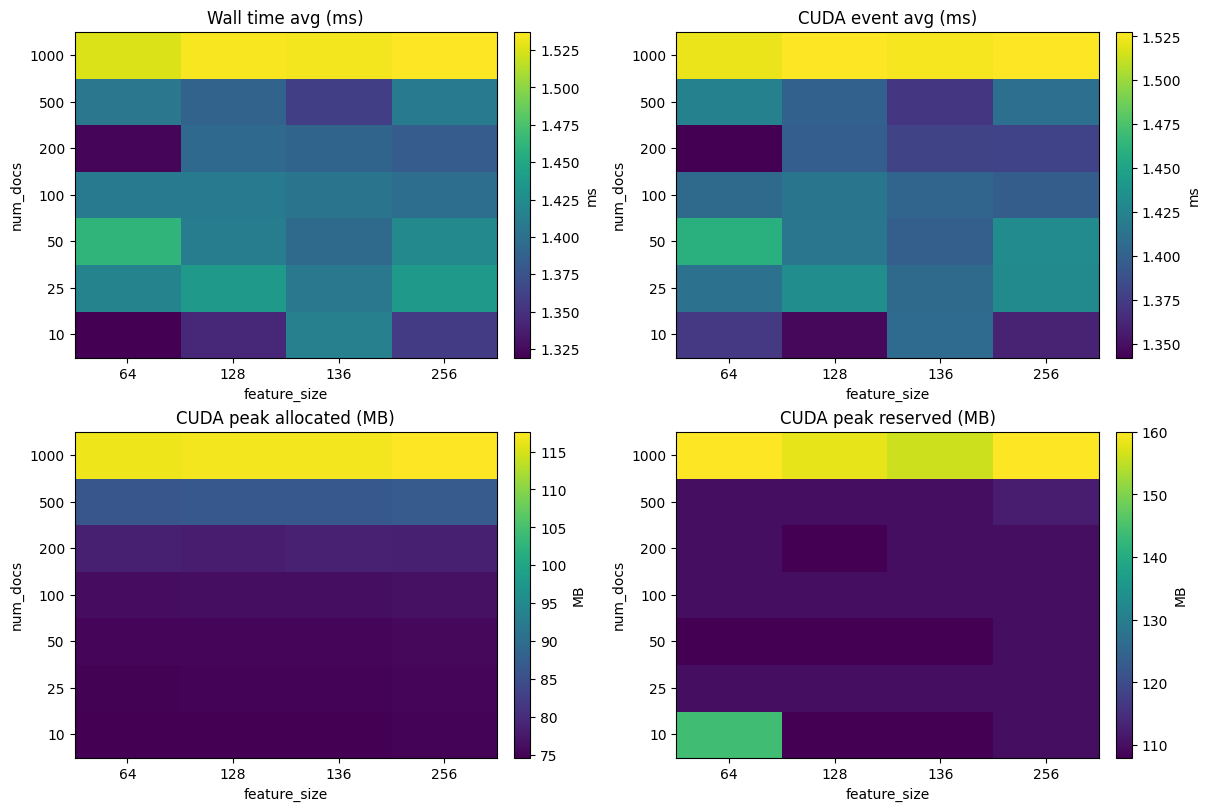

In [29]:
# Sweep over doc counts and feature sizes; plot latency and memory heatmaps
import numpy as np
import torch
import matplotlib.pyplot as plt

# Ensure model exists

# Parameter grid (edit as needed)
doc_counts = [10, 25, 50, 100, 200, 500, 1000]
feature_sizes = [64, 128, 136, 256]
repeats = 20

# Storage
wall_ms_avg = np.zeros((len(doc_counts), len(feature_sizes)), dtype=float)
event_ms_avg = np.zeros_like(wall_ms_avg)
mem_alloc_mb = np.zeros_like(wall_ms_avg)  # CUDA allocated peak (MB)
mem_resv_mb = np.zeros_like(wall_ms_avg)   # CUDA reserved peak (MB)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Sweep
for i, nd in enumerate(doc_counts):
    for j, fs in enumerate(feature_sizes):
        model = make_Encoder_model(input_dim=fs)
        model.to(device)
        x = torch.randn((1, nd, fs), device=device)
        # Time
        t_res = measure_inference_time(model, x, repeats=repeats, use_cuda_events=True)
        wall_ms_avg[i, j] = t_res['wall_ms_avg']
        event_ms_avg[i, j] = t_res['event_ms_avg'] if t_res['event_ms_avg'] is not None else np.nan
        # Memory
        m_res = measure_inference_peak_memory(model, x, steps=3)
        alloc_b = m_res['cuda_peak']['allocated_bytes']
        resv_b = m_res['cuda_peak']['reserved_bytes']
        mem_alloc_mb[i, j] = alloc_b / (1024**2)
        mem_resv_mb[i, j] = resv_b / (1024**2)

# Plot helpers
def plot_heatmap(ax, Z, x_ticks, y_ticks, title, cbar_label):
    im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis')
    ax.set_xticks(np.arange(len(x_ticks)))
    ax.set_xticklabels(x_ticks)
    ax.set_yticks(np.arange(len(y_ticks)))
    ax.set_yticklabels(y_ticks)
    ax.set_xlabel('feature_size')
    ax.set_ylabel('num_docs')
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
plot_heatmap(axes[0,0], wall_ms_avg, feature_sizes, doc_counts, 'Wall time avg (ms)', 'ms')
plot_heatmap(axes[0,1], event_ms_avg, feature_sizes, doc_counts, 'CUDA event avg (ms)', 'ms')
plot_heatmap(axes[1,0], mem_alloc_mb, feature_sizes, doc_counts, 'CUDA peak allocated (MB)', 'MB')
plot_heatmap(axes[1,1], mem_resv_mb, feature_sizes, doc_counts, 'CUDA peak reserved (MB)', 'MB')
plt.show()



In [ ]:
# Training measurement utilities (Adam + Cross_Entropy_point)
import torch
import time
import numpy as np
from typing import Dict, Any, Optional

from utils.loss_mask_utils import Cross_Entropy_point


def make_adam(model: torch.nn.Module, lr: float = 1e-3, weight_decay: float = 0.0) -> torch.optim.Optimizer:
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


def measure_training_time(
    model: torch.nn.Module,
    sample_inputs: torch.Tensor,
    sample_targets: torch.Tensor,
    repeats: int = 10,
    lr: float = 1e-3,
    use_cuda_events: bool = True,
) -> Dict[str, Any]:
    """
    Measures time for a single training step (forward + loss + backward + step), repeated N times.
    - sample_inputs: input batch on the same device as model
    - sample_targets: target tensor aligned with model output and Cross_Entropy_point expectations
    Returns avg and p95 wall/CUDA event timings (ms).
    """
    model.train()
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = sample_inputs.device

    # Ensure targets on correct device
    targets = sample_targets.to(device)

    optimizer = make_adam(model, lr=lr)
    loss_module = Cross_Entropy_point()

    def closure_loss(outputs: torch.Tensor) -> torch.Tensor:
        return loss_module(outputs, targets)

    # Warmup single step
    optimizer.zero_grad(set_to_none=True)
    out = model(sample_inputs)
    loss = closure_loss(out)
    loss.backward()
    optimizer.step()
    if device.type == 'cuda':
        torch.cuda.synchronize()

    wall_ms = []
    event_ms = []

    for _ in range(max(1, repeats)):
        optimizer.zero_grad(set_to_none=True)

        if device.type == 'cuda' and use_cuda_events:
            ev_start = torch.cuda.Event(enable_timing=True)
            ev_end = torch.cuda.Event(enable_timing=True)
            ev_start.record()

        t0 = time.perf_counter()
        out = model(sample_inputs)
        loss = closure_loss(out)
        loss.backward()
        optimizer.step()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        wall_ms.append((t1 - t0) * 1000.0)

        if device.type == 'cuda' and use_cuda_events:
            ev_end.record()
            torch.cuda.synchronize()
            event_ms.append(ev_start.elapsed_time(ev_end))

    def pct(arr, p):
        return float(np.percentile(np.array(arr, dtype=float), p)) if arr else None

    return {
        'device': str(device),
        'wall_ms_avg': float(np.mean(wall_ms)),
        'wall_ms_p95': pct(wall_ms, 95),
        'event_ms_avg': float(np.mean(event_ms)) if event_ms else None,
        'event_ms_p95': pct(event_ms, 95) if event_ms else None,
    }


def measure_training_memory_simple(
    model: torch.nn.Module,
    sample_inputs: torch.Tensor,
    sample_targets: torch.Tensor,
    lr: float = 1e-3,
    warmup: int = 1,
) -> Dict[str, Any]:
    """
    Measures CUDA peak memory for one training step using Adam and Cross_Entropy_point.
    sample_inputs and sample_targets must be on the model's device.
    Returns CUDA allocated/reserved peaks and static estimates (params, grads, optimizer state).
    """
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = sample_inputs.device

    optimizer = make_adam(model, lr=lr)
    loss_module = Cross_Entropy_point()

    def loss_fn(outputs: torch.Tensor) -> torch.Tensor:
        return loss_module(outputs, sample_targets)

    return measure_training_peak_memory(
        model=model,
        sample_inputs=sample_inputs,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        warmup=warmup,
    )

# Example usage (uncomment and adapt):
# device = next(model.parameters()).device
# x = torch.randn((1, 100, 136), device=device)
# y = torch.randint(0, 5, (1, 100), device=device)  # num_of_label=5 by default
# print(measure_training_time(model, x, y, repeats=5))
# print(measure_training_memory_simple(model, x, y, lr=1e-3))



In [ ]:
# Training sweep: time and memory heatmaps vs num_docs and feature_size
import numpy as np
import torch
import matplotlib.pyplot as plt

from utils.loss_mask_utils import Cross_Entropy_point

# Grid
train_doc_counts = [10, 25, 50, 100, 200, 500]
train_feature_sizes = [64, 128, 136, 220]
repeats = 10

# Prep containers
tr_wall_ms = np.zeros((len(train_doc_counts), len(train_feature_sizes)), dtype=float)
tr_event_ms = np.zeros_like(tr_wall_ms)
tr_mem_alloc_mb = np.zeros_like(tr_wall_ms)
tr_mem_resv_mb = np.zeros_like(tr_wall_ms)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Loss module (to build consistent targets)
num_labels = 5
loss_mod = Cross_Entropy_point(num_labels)

for i, nd in enumerate(train_doc_counts):
    for j, fs in enumerate(train_feature_sizes):
        # Build model per feature size
        model = make_Encoder_model(input_dim=fs)
        model.to(device)
        model.train()

        # Synthetic batch
        x = torch.randn((1, nd, fs), device=device)
        # Targets per doc: integers in [0, num_labels)
        y = torch.randint(0, num_labels, (1, nd), device=device)

        # Time
        t_res = measure_training_time(model, x, y, repeats=repeats, lr=1e-3, use_cuda_events=True)
        tr_wall_ms[i, j] = t_res['wall_ms_avg']
        tr_event_ms[i, j] = t_res['event_ms_avg'] if t_res['event_ms_avg'] is not None else np.nan

        # Memory
        m_res = measure_training_memory_simple(model, x, y, lr=1e-3, warmup=1)
        alloc_b = m_res['cuda_peak']['allocated_bytes']
        resv_b = m_res['cuda_peak']['reserved_bytes']
        tr_mem_alloc_mb[i, j] = alloc_b / (1024**2)
        tr_mem_resv_mb[i, j] = resv_b / (1024**2)

# Plot helper
def plot_heatmap(ax, Z, x_ticks, y_ticks, title, cbar_label):
    im = ax.imshow(Z, origin='lower', aspect='auto', cmap='magma')
    ax.set_xticks(np.arange(len(x_ticks)))
    ax.set_xticklabels(x_ticks)
    ax.set_yticks(np.arange(len(y_ticks)))
    ax.set_yticklabels(y_ticks)
    ax.set_xlabel('feature_size')
    ax.set_ylabel('num_docs')
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
plot_heatmap(axes[0,0], tr_wall_ms, train_feature_sizes, train_doc_counts, 'Train wall time avg (ms)', 'ms')
plot_heatmap(axes[0,1], tr_event_ms, train_feature_sizes, train_doc_counts, 'Train CUDA event avg (ms)', 'ms')
plot_heatmap(axes[1,0], tr_mem_alloc_mb, train_feature_sizes, train_doc_counts, 'Train CUDA peak allocated (MB)', 'MB')
plot_heatmap(axes[1,1], tr_mem_resv_mb, train_feature_sizes, train_doc_counts, 'Train CUDA peak reserved (MB)', 'MB')
plt.show()

